In [6]:
threshold_multiplier = 3.0

In [1]:
import pandas as pd

def load_and_preprocess_data(filepath: str):
    """Load Amazon reviews data from JSON lines and preprocess for drift detection."""
    # Load data
    data = pd.read_json(filepath, lines=True)
    # Filter out neutral ratings and binarize the rating
    data = data[data["rating"] != 3]
    data["rating"] = data["rating"].apply(lambda x: 1 if x > 3 else 0)
    # Filter by timestamp if needed (e.g., after Jan 2015 for this experiment)
    data = data[data["timestamp"] > '2015-01-01']
    # Set timestamp as index and sort chronologically
    data = data.set_index("timestamp")
    data.sort_index(inplace=True)
    return data

# Load the dataset (adjust the file path as needed)
data = load_and_preprocess_data("Amazon_Fashion.jsonl")
print(f"Loaded {len(data)} records. Data columns: {list(data.columns)}")
# Example output: Loaded 800000 records. Data columns: ['asin', 'parent_asin', 'user_id', 'rating', 'year', 'month', 'day', 'drift_flag']


Loaded 2166931 records. Data columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'helpful_vote', 'verified_purchase']


In [3]:
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM

def train_deepfm_model(data: pd.DataFrame, sparse_features: list, target: str, embedding_dim: int = 64, epochs: int = 2, batch_size: int = 1024):
    """
    Train a DeepFM model on the given data for the binary classification task.
    Returns the trained model.
    """
    # Label encode categorical features
    for feat in sparse_features:
        lbe = LabelEncoder()
        data[feat] = lbe.fit_transform(data[feat])
    # Define feature columns for DeepFM
    fixlen_feature_columns = [SparseFeat(feat, vocabulary_size=data[feat].nunique(), embedding_dim=embedding_dim)
                               for feat in sparse_features]
    linear_feature_columns = fixlen_feature_columns
    dnn_feature_columns = fixlen_feature_columns
    feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)
    # Prepare model input dict
    model_input = {name: data[name].values for name in feature_names}
    # Initialize DeepFM model
    # Decide on device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary', device=device)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
    # Train the model (using full data here; adjust as needed for a baseline-only training scenario)
    model.fit(model_input, data[target].values, batch_size=batch_size, epochs=epochs, verbose=3, validation_split=0.1)
    # Switch model to evaluation mode for inference
    model.eval()
    return model

# Define which features are sparse categorical and train the model
sparse_features = ["asin", "parent_asin", "user_id"]
target = "rating"
embedding_dim = 64
model = train_deepfm_model(data, sparse_features, target, embedding_dim=embedding_dim, epochs=2)


mps
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch
Epoch 1/2
289s - loss:  0.4877
Epoch 2/2
277s - loss:  0.1152


In [4]:
def split_into_windows(data: pd.DataFrame, n_windows: int):
    """
    Split the data into n_windows sequential time-ordered segments (windows).
    Returns a list of dataframes, one per window.
    """
    # Use numpy array_split to split indices into roughly equal segments
    indices = np.array(data.index)  # numpy array of timestamps
    windows = []
    split_indices = np.array_split(indices, n_windows)
    for inds in split_indices:
        # Create each window DataFrame by selecting rows for those indices
        # Ensure inds are sorted (they should already be since data is time-ordered)
        window_df = data.loc[inds]
        windows.append(window_df)
    return windows

# Define rolling window parameters
n_windows = 300  # total number of windows to split the timeline into
baseline_fraction = 0.3  # use first 30% of windows as baseline period
windows = split_into_windows(data, n_windows)
baseline_window_count = max(1, int(len(windows) * baseline_fraction))
print(f"Total windows: {len(windows)}; Using first {baseline_window_count} windows as baseline.")


Total windows: 300; Using first 90 windows as baseline.


In [9]:
from driftwatch.embedding_tracker import EmbeddingTracker

def extract_embeddings(model, batch_df: pd.DataFrame, sparse_features: list):
    """
    Extract the concatenated embeddings for all samples in batch_df using the trained model.
    Returns a NumPy array of shape (num_samples, total_embedding_dim).
    """
    # Prepare model input for the batch
    batch_input = {feat: batch_df[feat].values for feat in sparse_features}
    # Forward pass (ensure no gradient computation)
    with torch.no_grad():
        _ = model.predict(batch_input)  # run through model to ensure embeddings are materialized (if needed)
    # Collect embeddings from each feature's embedding layer
    embeddings_list = []
    for feat in sparse_features:
        # Get the full embedding matrix for this feature and pick the rows for our batch indices
        emb_matrix = model.embedding_dict[feat].weight.detach().cpu().numpy()
        indices = batch_input[feat]  # these are the encoded indices of the feature values in this batch
        batch_emb = emb_matrix[indices]  # shape: (num_samples, embedding_dim)
        embeddings_list.append(batch_emb)
    # Concatenate embeddings from all features to form the complete representation
    embeddings = np.concatenate(embeddings_list, axis=1)  # shape: (num_samples, embedding_dim * num_features)
    return embeddings

def establish_baseline(embedding_tracker: EmbeddingTracker, windows: list, baseline_count: int, distance_metric: str):
    """
    Use the first baseline_count windows to establish the baseline distribution in the embedding tracker.
    Returns a dictionary with baseline drift distances and the initial threshold.
    """
    baseline_distances = []
    # Iterate over baseline windows
    for i in range(baseline_count):
        window_df = windows[i]
        emb = extract_embeddings(model, window_df, sparse_features)
        # If using vector-based distance, use the mean embedding; if distribution-based, use full embeddings
        emb_input = emb if embedding_tracker.is_distribution_mode else np.mean(emb, axis=0)
        if i == 0:
            # Initialize baseline in tracker with the first window
            embedding_tracker.update(emb_input)
            baseline_distances.append(0.0)  # no drift distance for the first window (baseline reference)
        else:
            # Compute distance of this window's embedding distribution to current baseline
            drift_dist = embedding_tracker.compute_distance(emb_input)
            baseline_distances.append(float(drift_dist))
            # Update the baseline tracker with this window (assuming it's part of baseline distribution)
            embedding_tracker.update(emb_input)
    # Calculate initial drift threshold as mean + k*std of baseline distances (excluding the very first 0.0)
    if len(baseline_distances) > 1:
        baseline_dist_array = np.array(baseline_distances[1:])  # exclude the initial 0.0
        initial_threshold = np.mean(baseline_dist_array) + threshold_multiplier * np.std(baseline_dist_array)
    else:
        initial_threshold = float(baseline_distances[0])  # if only one baseline window, use its (zero) distance
    # For baseline period, we consider no drift occurred, so labels are 0
    baseline_labels = [0] * len(baseline_distances)
    # Also prepare a threshold list for baseline windows (initial_threshold applied throughout baseline)
    baseline_thresholds = [initial_threshold] * len(baseline_distances)
    return {
        "distances": baseline_distances,
        "thresholds": baseline_thresholds,
        "labels": baseline_labels,
        "initial_threshold": initial_threshold
    }

def detect_drift(embedding_tracker: EmbeddingTracker, windows: list, baseline_count: int, initial_threshold: float,
                 threshold_window: int = 50, threshold_multiplier: float = 3.0, adaptive_update: bool = False):
    """
    Compute drift distances for windows beyond the baseline period and detect drift events.
    Uses a rolling window of past `threshold_window` drift scores to update the threshold.
    If adaptive_update is True, update the baseline tracker with windows that are NOT flagged as drift.
    Returns a dict with drift distances, thresholds, and drift labels for the post-baseline windows.
    """
    drift_distances = []
    thresholds = []
    drift_labels = []
    # Iterate through each window after the baseline period
    for j in range(baseline_count, len(windows)):
        window_df = windows[j]
        emb = extract_embeddings(model, window_df, sparse_features)
        emb_input = emb if embedding_tracker.is_distribution_mode else np.mean(emb, axis=0)
        # Compute the embedding distance to baseline distribution
        drift_dist = embedding_tracker.compute_distance(emb_input)
        drift_distances.append(float(drift_dist))
        # Compute dynamic threshold based on recent `threshold_window` distances
        if len(drift_distances) > threshold_window:
            recent = drift_distances[-threshold_window:]  # last N drift distances
            thresh = np.mean(recent) + threshold_multiplier * np.std(recent)
        else:
            thresh = initial_threshold
        thresholds.append(float(thresh))
        # Determine drift label for this window
        if drift_dist > thresh:
            drift_labels.append(1)  # drift detected
        else:
            drift_labels.append(0)  # no drift
            if adaptive_update:
                # Optionally update baseline tracker with this window if it's considered stable (no drift)
                embedding_tracker.update(emb_input)
    return {
        "distances": drift_distances,
        "thresholds": thresholds,
        "labels": drift_labels
    }

# Set up the EmbeddingTracker with desired distance metric
distance_metric = "mahalanobis"  # e.g., "mahalanobis", "euclidean", "cosine", "kl", "js", "hellinger", etc.
# Initialize EmbeddingTracker (embedding_dim = embedding_dim * number of features if using concatenated embeddings)
tracker = EmbeddingTracker(embedding_dim=embedding_dim * len(sparse_features),
                            distance_name=distance_metric, alpha=0.01)
# Establish baseline distribution
baseline_result = establish_baseline(tracker, windows, baseline_window_count, distance_metric)
initial_threshold = baseline_result["initial_threshold"]
print(f"Initial drift threshold (baseline): {initial_threshold:.4f}")
# Run drift detection on remaining windows
drift_result = detect_drift(tracker, windows, baseline_window_count, initial_threshold,
                            threshold_window=50, threshold_multiplier=3.0, adaptive_update=False)


Initial drift threshold (baseline): 0.0542


Drift results saved to 'drift_detection_results.csv'.


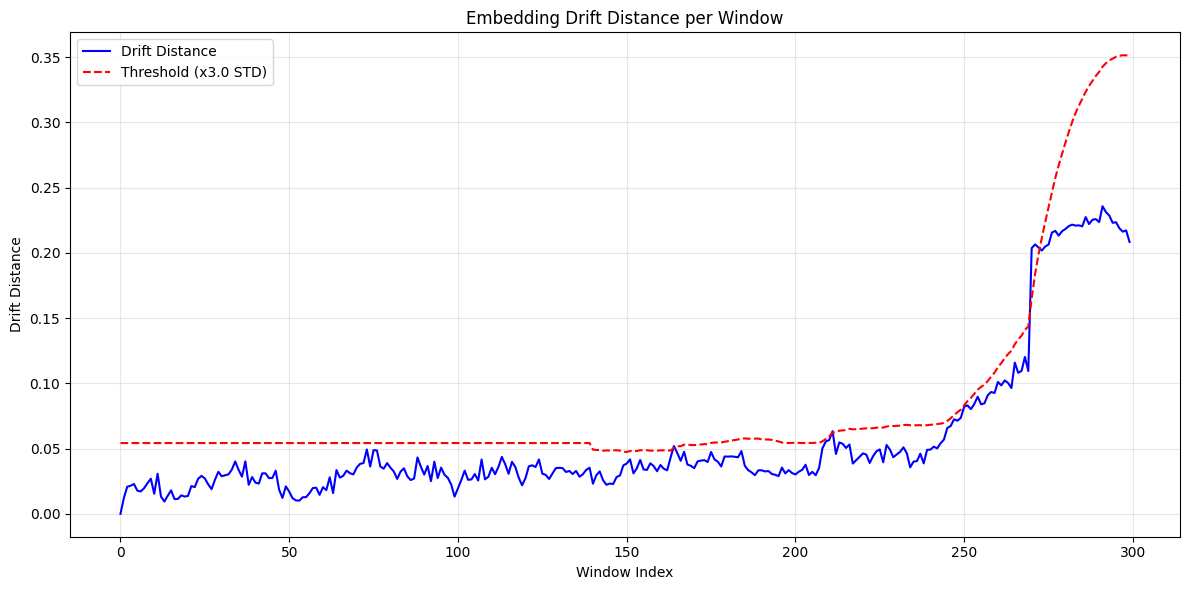

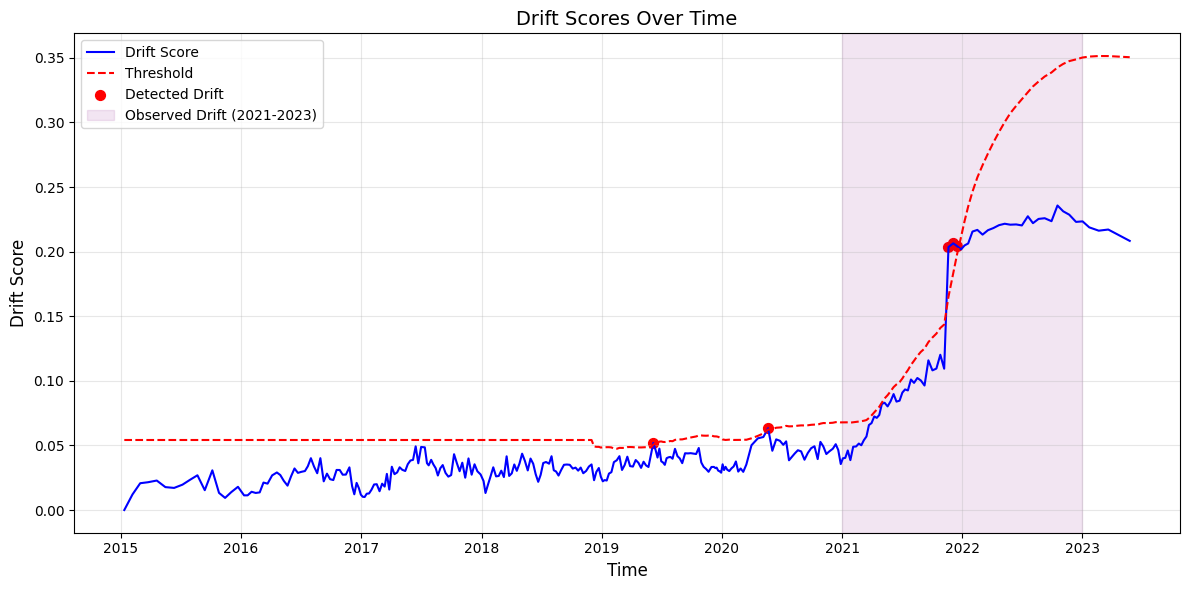

In [10]:
import matplotlib.pyplot as plt


# Combine baseline and detection results
all_distances = baseline_result["distances"] + drift_result["distances"]
all_thresholds = baseline_result["thresholds"] + drift_result["thresholds"]
all_labels = baseline_result["labels"] + drift_result["labels"]
# Construct timestamps for each window (use the mean timestamp of each window as its representative time)
window_times = [win.index.mean() for win in windows]

# Save drift distances and thresholds to disk as a CSV
results_df = pd.DataFrame({
    "window_time": window_times,
    "drift_distance": all_distances,
    "threshold": all_thresholds,
    "drift_detected": all_labels
})
results_df.to_csv("drift_detection_results.csv", index=False)
print("Drift results saved to 'drift_detection_results.csv'.")

# Plot drift distance and threshold over window index
plt.figure(figsize=(12, 6))
plt.plot(all_distances, label="Drift Distance", color='blue')
plt.plot(all_thresholds, label=f"Threshold (x{threshold_multiplier} STD)", color='red', linestyle="--")
plt.title("Embedding Drift Distance per Window")
plt.xlabel("Window Index")
plt.ylabel("Drift Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("drift_distance_by_index.png")
plt.show()

# Plot drift distance over time with threshold and detected drift points
plt.figure(figsize=(12, 6))
plt.plot(window_times, all_distances, label="Drift Score", color="blue")
plt.plot(window_times, all_thresholds, label="Threshold", color="red", linestyle="--")
# Highlight detected drift windows on the plot
drift_times = [t for t, lbl in zip(window_times, all_labels) if lbl == 1]
drift_scores = [d for d, lbl in zip(all_distances, all_labels) if lbl == 1]
if drift_times:
    plt.scatter(drift_times, drift_scores, color="red", marker="o", s=50, label="Detected Drift")
# Optionally highlight a known drift period (e.g., 2021–2023) if relevant
plt.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2023-01-01"), color="purple", alpha=0.1, label="Observed Drift (2021-2023)")
plt.title("Drift Scores Over Time", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Drift Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("drift_score_over_time.png")
plt.show()
